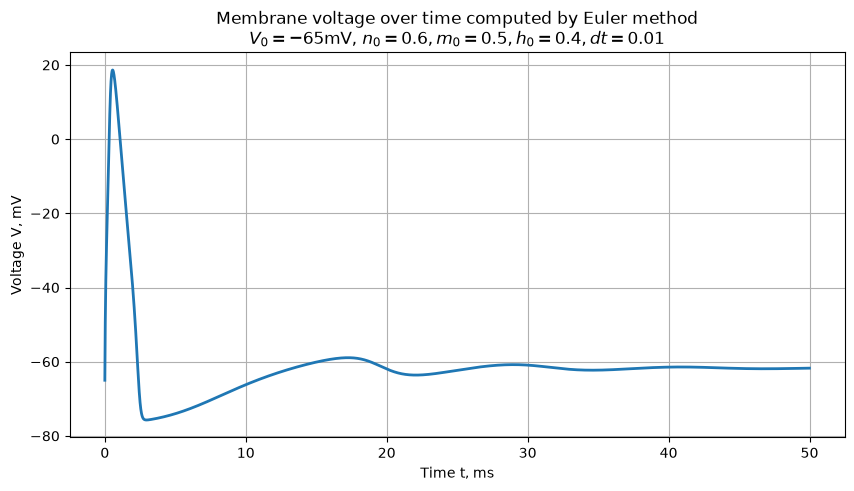

In [3]:

from aufgabe2.ode_solver_euler import euler_method
import matplotlib.pyplot as plt
import numpy as np

V_0 = -65
n_0 = 0.6
m_0 = 0.5
h_0 = 0.4
x = np.array([V_0,n_0, m_0, h_0])
tuple_of_constants = (1, 36, 120, 0.3, -77, 50, -54.387)

t_a = 0
t_b = 50
dt = 0.01

I_0 = 5
I = lambda t: I_0
v = euler_method(x, t_a, t_b, dt, I, tuple_of_constants) [0: ,0]
tpoints = np.arange(0, 50, dt)
plt.figure(figsize=(10, 5))
plt.plot(tpoints,v, linewidth=2)
plt.title("Membrane voltage over time computed by Euler method\n" + rf"$V_0 = {V_0}$mV, $n_0 = {n_0}, m_0 = {m_0}, h_0 = {h_0}, dt = {dt}$")
plt.xlabel("Time t, ms")
plt.ylabel("Voltage V, mV")
plt.grid(True)
plt.show()


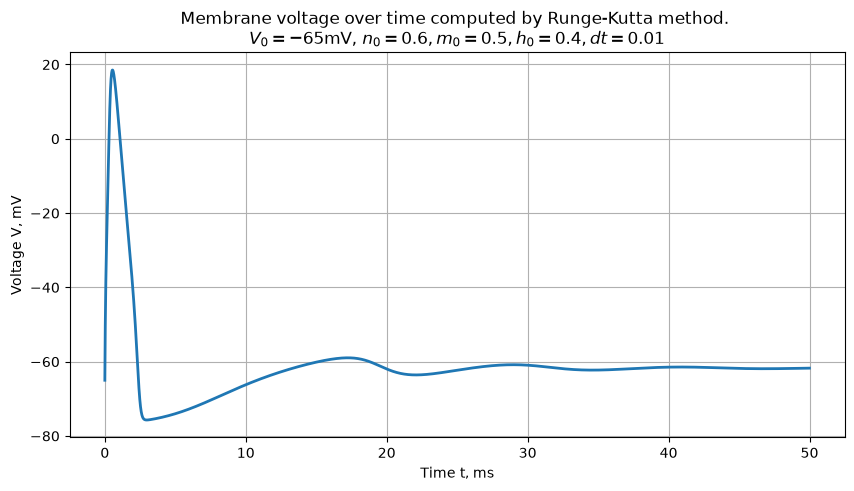

In [33]:
from aufgabe2.ode_solver_runge_kutta import runge_kutta_method


v = runge_kutta_method(x, t_a, t_b, dt, I, tuple_of_constants) [0: ,0]
plt.figure(figsize=(10, 5))
plt.plot(tpoints,v, linewidth=2)
plt.title("Membrane voltage over time computed by Runge-Kutta method. \n" + rf"$V_0 = {V_0}$mV, $n_0 = {n_0}, m_0 = {m_0}, h_0 = {h_0}, dt = {dt}$")
plt.xlabel("Time t, ms")
plt.ylabel("Voltage V, mV")
plt.grid(True)
plt.show()

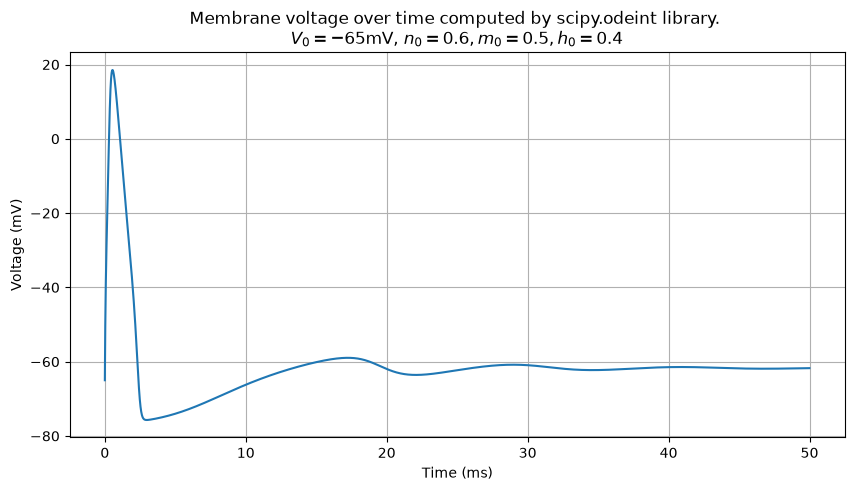

In [34]:
import scipy.integrate as spi
import aufgabe2.equations as eq
state_0 = [-65, 0.6, 0.5, 0.4]

I = 5

def hh_system(state, t, I, tuple_of_constants : tuple[float]):
    return eq.equations_vector(state, I, tuple_of_constants)

solution = spi.odeint(hh_system, state_0, tpoints, args=(I,tuple_of_constants) )

V_t = solution[:, 0]


# --- Plot ---
plt.figure(figsize=(10, 5))
plt.plot(tpoints, V_t)
plt.xlabel("Time $t$, ms")
plt.ylabel('Voltage, mV')
plt.title("Membrane voltage over time computed by scipy.odeint library. \n" + rf"$V_0 = {V_0}$mV, $n_0 = {n_0}, m_0 = {m_0}, h_0 = {h_0}$")
plt.grid(True)
plt.show()

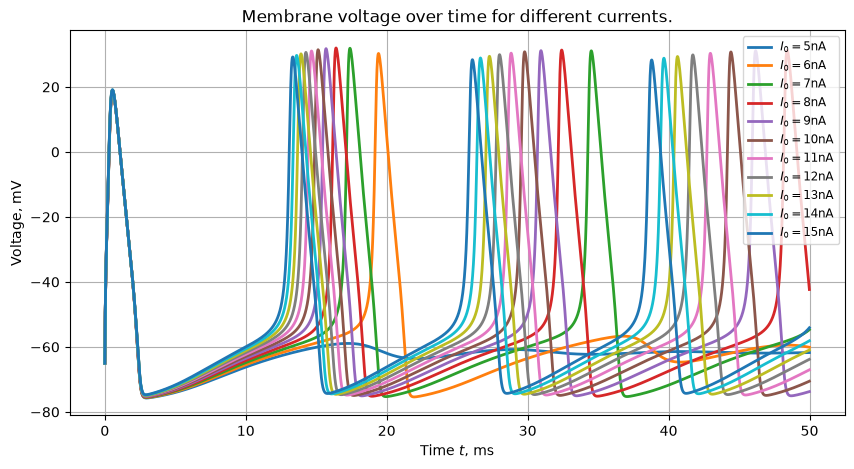

In [9]:
plt.figure(figsize=(10, 5))

current_values = list(range(5, 16))
tpoints = np.arange(t_a, t_b, dt)

for i in current_values:
    I_func = lambda t, val=i: val
    temp = euler_method(x, t_a, t_b, dt, I_func, tuple_of_constants)[0:, 0]
    plt.plot(tpoints, temp, linewidth=2, label=f"$I_0 = {i}$nA")

# 2. Add labels, title, grid, and legend to the active figure
plt.xlabel("Time $t$, ms")
plt.ylabel("Voltage, mV")
plt.title("Membrane voltage over time for different currents.")  # Fixed string quote here
plt.grid(True)

# 3. Place the legend (adjust bbox_to_anchor if it overlaps with your lines)
plt.legend(loc="upper right", fontsize="small")

# 4. Show everything together
plt.show()


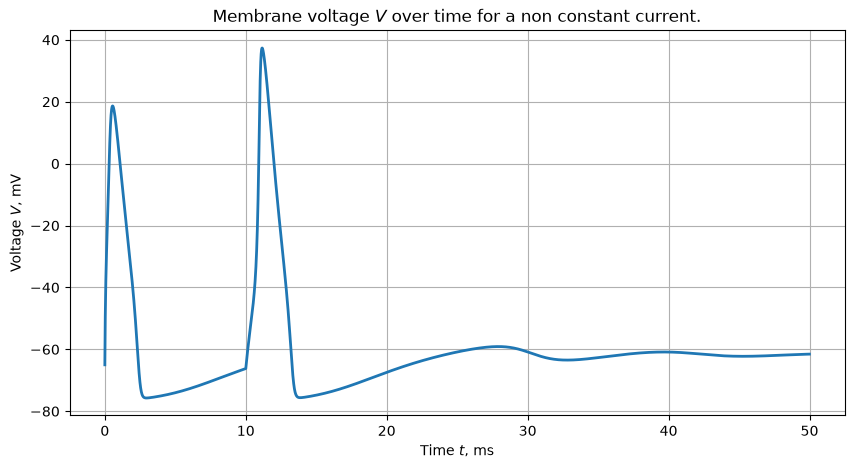

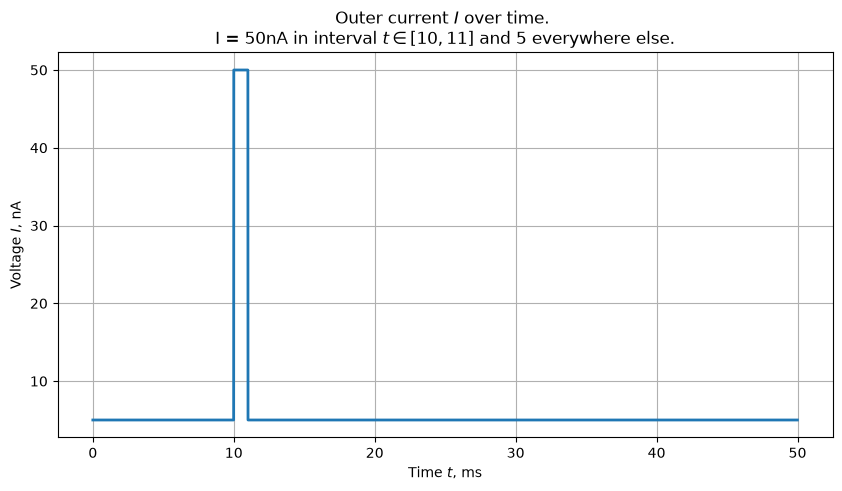

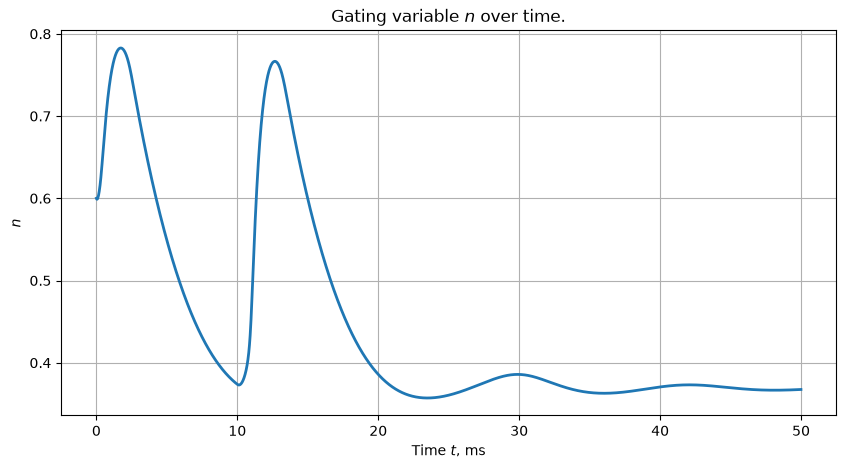

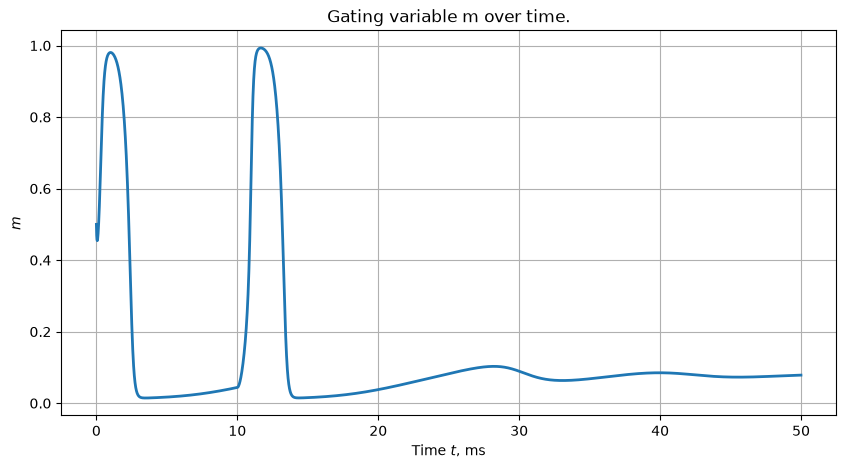

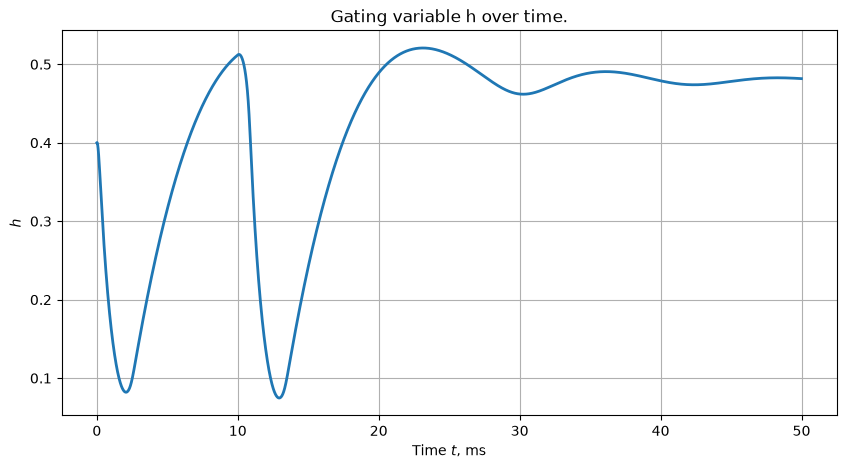

In [12]:
I_func = lambda t: 50 if (10 <= t <= 11) else I_0
I_values = np.array([I_func(t) for t in tpoints])
s = euler_method(x, t_a, t_b, dt, I_func, tuple_of_constants)
v = s[0: ,0]
n = s[0: ,1]
m = s[0: ,2]
h = s[0: ,3]
tpoints = np.arange(0, 50, dt)

plt.figure(figsize=(10, 5))
plt.plot(tpoints,v, linewidth=2)
plt.xlabel("Time $t$, ms")
plt.ylabel("Voltage $V$, mV")
plt.title("Membrane voltage $V$ over time for a non constant current.")
plt.grid(True)

plt.figure(figsize=(10, 5))
plt.plot(tpoints,I_values, linewidth=2)
plt.xlabel("Time $t$, ms")
plt.ylabel("Voltage $I$, nA")
plt.title("Outer current $I$ over time. \n" + rf"I = 50nA in interval $t \in [10,11]$ and {I_0} everywhere else.")
plt.grid(True)

plt.figure(figsize=(10, 5))
plt.plot(tpoints,n, linewidth=2)
plt.xlabel("Time $t$, ms")
plt.ylabel("$n$")
plt.title("Gating variable $n$ over time.")
plt.grid(True)

plt.figure(figsize=(10, 5))
plt.plot(tpoints,m, linewidth=2)
plt.xlabel("Time $t$, ms")
plt.ylabel("$m$")
plt.title("Gating variable m over time.")
plt.grid(True)

plt.figure(figsize=(10, 5))
plt.plot(tpoints,h, linewidth=2)
plt.xlabel("Time $t$, ms")
plt.ylabel("$h$")
plt.title("Gating variable h over time.")
plt.grid(True)



plt.show()
